## __Data Science: Capstone Part 1: Lightning Talk 1__

### Overview

In the field of data science, good projects are practical. Your capstone project should be manageable and affect a real world audience. This might be a domain you are familiar with, a particular interest you have, something that affects a community you are involved in, or an area that relates to a field you wish to work in.

One of the best ways to test ideas quickly is to share them with others. A good data scientist has to be comfortable discussing ideas and presenting to audiences. That's why for Part 1 of your Capstone project, you'll be preparing a lightning talk on some potential interest areas and datasets.

This deliverable will provide you with guidance to help you select an awesome topic and begin to build a polished Capstone project.

__Goal__: Host a lightning talk presentation describing at least three project proposals, including associated data, problem statement, goals, approach, and basic EDA.

### REQUIRED

__Foreach Topic__:
- Problem Statement
- Goals
- Approach
- Data Source(s)
- Data Info. (basic EDA)

Dataset should have __15k+__ rows and __10+__ columns

___Remember, if you can't find data to support your topic, then you can't move forward.___

# Topic 1 : Bank Loan Status

## Problem Statement

Lenders must decide whether a borrower is likely to repay a loan before it's issued, but manual credit assessment is slow, inconsistent, and doesn't scale. This project uses borrower and loan-level financial data to predict whether a loan will end in Fully Paid or Charged Off (default), so risk can be flagged earlier and more consistently than rule-based scoring alone.


## Goals

**1-** Clean a large, real-world dataset with substantial missingness, duplicate records, and data-entry errors (sentinel values, out-of-range credit scores)

**2-** Build a binary classifier that predicts loan outcome from features available at origination

**3-** Identify which financial and credit-history factors contribute most to default risk

**4-** Evaluate performance appropriately given class imbalance (77% paid / 23% charged off), prioritizing recall on defaults over raw accuracy

## Approach

**1-** EDA — quantify missingness, duplicates, outliers

**2-** Clean — fix sentinel values, invalid scores, inconsistent categories, string fields

**3-** Handle missing Credit Score/Income (co-missing) and delinquency data (likely informative)

**4-** Feature engineering (e.g. debt-to-income) and encoding

**5-** Train logistic regression baseline + tree-based models, stratified split

**6-** Evaluate on precision/recall/F1/ROC-AUC for defaults; interpret feature importance


## Data Info
Data Source : https://www.kaggle.com/datasets/zaurbegiev/my-dataset?select=credit_train.csv

## Data Dictionary

| Column | Type | Description |
| --- | --- | --- |
| Loan ID | string | Unique identifier for the loan (UUID format) |
| Customer ID | string | Unique identifier for the customer (UUID format) |
| Loan Status | string | **Target variable** — loan outcome: "Fully Paid" or "Charged Off" |
| Current Loan Amount | float | Loan amount issued to the borrower |
| Term | string | Loan repayment term: "Short Term" or "Long Term" |
| Credit Score | float | Borrower's credit score at time of application |
| Annual Income | float | Borrower's stated annual income |
| Years in current job | string | Length of employment at current job (e.g. "8 years", "10+ years", "< 1 year") |
| Home Ownership | string | Borrower's home ownership status (e.g. "Home Mortgage", "Own Home", "Rent") |
| Purpose | string | Stated purpose of the loan (e.g. "Debt Consolidation", "Home Improvements") |
| Monthly Debt | float | Borrower's total monthly debt payments |
| Years of Credit History | float | Number of years the borrower has had credit history |
| Months since last delinquent | float | Number of months since borrower's last delinquent payment |
| Number of Open Accounts | float | Count of currently open credit accounts |
| Number of Credit Problems | float | Count of recorded credit problems (e.g. delinquencies, collections) |
| Current Credit Balance | float | Borrower's current total credit balance owed |
| Maximum Open Credit | float | Highest credit limit across borrower's open accounts |
| Bankruptcies | float | Number of bankruptcies on record |
| Tax Liens | float | Number of tax liens on record |

In [1]:
# start you EDA
import pandas as pd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('./Data/Bank_Loan_Status.csv')
df.head()

,Loan ID,Customer ID,Loan Status,Current Loan Amount,Term,Credit Score,Annual Income,Years in current job,Home Ownership,Purpose,Monthly Debt,Years of Credit History,Months since last delinquent,Number of Open Accounts,Number of Credit Problems,Current Credit Balance,Maximum Open Credit,Bankruptcies,Tax Liens
0,14dd8831-6af5-400b-83ec-68e61888a048,981165ec-3274-42f5-a3b4-d104041a9ca9,Fully Paid,445412.0,Short Term,709.0,1167493.0,8 years,Home Mortgage,Home Improvements,5214.74,17.2,NaN,6.0,1.0,228190.0,416746.0,1.0,0.0
1,4771cc26-131a-45db-b5aa-537ea4ba5342,2de017a3-2e01-49cb-a581-08169e83be29,Fully Paid,262328.0,Short Term,NaN,NaN,10+ years,Home Mortgage,Debt Consolidation,33295.98,21.1,8.0,35.0,0.0,229976.0,850784.0,0.0,0.0
2,4eed4e6a-aa2f-4c91-8651-ce984ee8fb26,5efb2b2b-bf11-4dfd-a572-3761a2694725,Fully Paid,99999999.0,Short Term,741.0,2231892.0,8 years,Own Home,Debt Consolidation,29200.53,14.9,29.0,18.0,1.0,297996.0,750090.0,0.0,0.0
3,77598f7b-32e7-4e3b-a6e5-06ba0d98fe8a,e777faab-98ae-45af-9a86-7ce5b33b1011,Fully Paid,347666.0,Long Term,721.0,806949.0,3 years,Own Home,Debt Consolidation,8741.90,12.0,NaN,9.0,0.0,256329.0,386958.0,0.0,0.0
4,d4062e70-befa-4995-8643-a0de73938182,81536ad9-5ccf-4eb8-befb-47a4d608658e,Fully Paid,176220.0,Short Term,NaN,NaN,5 years,Rent,Debt Consolidation,20639.70,6.1,NaN,15.0,0.0,253460.0,427174.0,0.0,0.0


In [3]:
# What is your target column and what does it represent?

# Target: 'Loan Status'
# Represents the outcome of the loan — whether the borrower fully repaid it
# or defaulted (Charged Off). This is what we're trying to predict.

print(df['Loan Status'].unique())

<ArrowStringArray>
['Fully Paid', 'Charged Off', nan]
Length: 3, dtype: str


Loan Status
Fully Paid     77361
Charged Off    22639
Name: count, dtype: int64
Loan Status
Fully Paid     77.4
Charged Off    22.6
Name: proportion, dtype: float64


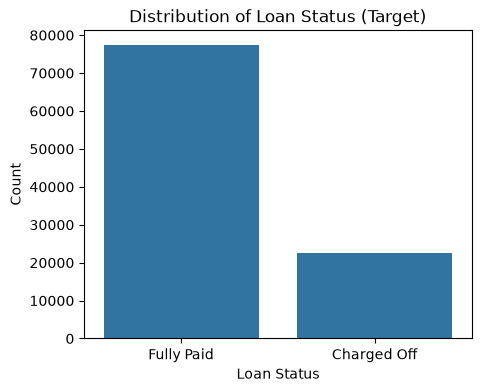

In [4]:
# Is your target categorical or continuous? is it balanced (Plot the distribution)?

# Categorical (binary classification): Fully Paid vs Charged Off

print(df['Loan Status'].value_counts())
print(df['Loan Status'].value_counts(normalize=True).round(3) * 100)

plt.figure(figsize=(5,4))
sns.countplot(data=df, x='Loan Status', order=df['Loan Status'].value_counts().index)
plt.title('Distribution of Loan Status (Target)')
plt.ylabel('Count')
plt.show()

# The data is imbalanced

In [5]:
# What types of features do you have (categorical / numerical)? how many of each ?
cat_cols = df.select_dtypes(include=['object','str']).columns.tolist()
num_cols = df.select_dtypes(include='number').columns.tolist()

id_cols = ['Loan ID', 'Customer ID']
cat_features = [c for c in cat_cols if c not in id_cols + ['Loan Status']]
num_features = num_cols

print(f"Categorical features {len(cat_features)}: {cat_features}")
print(f"Numerical features {len(num_features)}: {num_features}")
print(f"ID columns excluded: {id_cols}")
print(f"Target: Loan Status")

Categorical features 4: ['Term', 'Years in current job', 'Home Ownership', 'Purpose']
Numerical features 12: ['Current Loan Amount', 'Credit Score', 'Annual Income', 'Monthly Debt', 'Years of Credit History', 'Months since last delinquent', 'Number of Open Accounts', 'Number of Credit Problems', 'Current Credit Balance', 'Maximum Open Credit', 'Bankruptcies', 'Tax Liens']
ID columns excluded: ['Loan ID', 'Customer ID']
Target: Loan Status


In [6]:
# How many null values does each feature have? what's your plan for each?
df.isnull().sum()

Loan ID                           514
Customer ID                       514
Loan Status                       514
Current Loan Amount               514
Term                              514
Credit Score                    19668
Annual Income                   19668
Years in current job             4736
Home Ownership                    514
Purpose                           514
Monthly Debt                      514
Years of Credit History           514
Months since last delinquent    53655
Number of Open Accounts           514
Number of Credit Problems         514
Current Credit Balance            514
Maximum Open Credit               516
Bankruptcies                      718
Tax Liens                         524
dtype: int64

 All columns (baseline 514 nulls): blank trailing rows 
- Credit Score / Annual Income (19,154, co-missing): investigate pattern then impute or drop
- Years in current job (4,222): parse strings to numeric then impute median/mode
- Months since last delinquent (53,141): likely = never delinquent 
- Maximum Open Credit (2): impute or drop
- Bankruptcies (204): impute 0
- Tax Liens (10): impute 0

Loan_Status_encoded             1.000000
Credit Score                    0.467328
Number of Open Accounts         0.011949
Tax Liens                       0.010217
Monthly Debt                    0.007916
Number of Credit Problems       0.002358
Bankruptcies                   -0.006584
Maximum Open Credit            -0.008404
Current Credit Balance         -0.009663
Months since last delinquent   -0.013655
Years of Credit History        -0.023705
Annual Income                  -0.053135
Current Loan Amount            -0.194633
Name: Loan_Status_encoded, dtype: float64


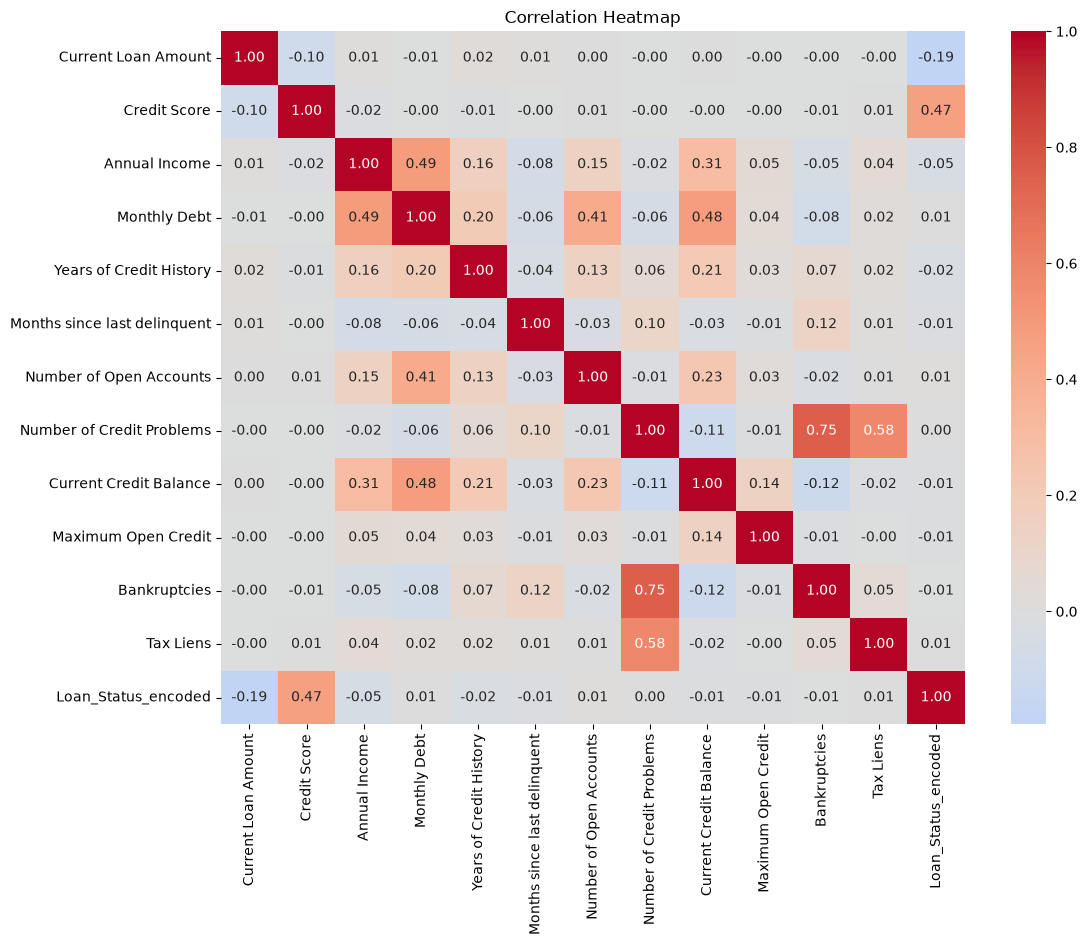

In [7]:
# Which features are most correlated with your target, and with each other?

# Encode target numerically for correlation purposes
df['Loan_Status_encoded'] = df['Loan Status'].map({'Fully Paid': 0, 'Charged Off': 1})

# Correlation with target
corr_with_target = df[num_features + ['Loan_Status_encoded']].corr()['Loan_Status_encoded'].sort_values(ascending=False)
print(corr_with_target)

# Full correlation heatmap among numeric features
plt.figure(figsize=(12,9))
sns.heatmap(df[num_features + ['Loan_Status_encoded']].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

In [8]:
# Are there outliers? how would you handle them?

df.describe()

,Current Loan Amount,Credit Score,Annual Income,Monthly Debt,Years of Credit History,Months since last delinquent,Number of Open Accounts,Number of Credit Problems,Current Credit Balance,Maximum Open Credit,Bankruptcies,Tax Liens,Loan_Status_encoded
count,1.000000e+05,80846.000000,8.084600e+04,100000.000000,100000.000000,46859.000000,100000.00000,100000.000000,1.000000e+05,9.999800e+04,99796.000000,99990.000000,100000.000000
mean,1.176045e+07,1076.456089,1.378277e+06,18472.412336,18.199141,34.901321,11.12853,0.168310,2.946374e+05,7.607984e+05,0.117740,0.029313,0.226390
std,3.178394e+07,1475.403791,1.081360e+06,12174.992609,7.015324,21.997829,5.00987,0.482705,3.761709e+05,8.384503e+06,0.351424,0.258182,0.418496
min,1.080200e+04,585.000000,7.662700e+04,0.000000,3.600000,0.000000,0.00000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000
25%,1.796520e+05,705.000000,8.488440e+05,10214.162500,13.500000,16.000000,8.00000,0.000000,1.126700e+05,2.734380e+05,0.000000,0.000000,0.000000
50%,3.122460e+05,724.000000,1.174162e+06,16220.300000,16.900000,32.000000,10.00000,0.000000,2.098170e+05,4.678740e+05,0.000000,0.000000,0.000000
75%,5.249420e+05,741.000000,1.650663e+06,24012.057500,21.700000,51.000000,14.00000,0.000000,3.679588e+05,7.829580e+05,0.000000,0.000000,0.000000
max,1.000000e+08,7510.000000,1.655574e+08,435843.280000,70.500000,176.000000,76.00000,15.000000,3.287897e+07,1.539738e+09,7.000000,15.000000,1.000000


describe() confirms known issues: Current Loan Amount contains a sentinel value (100,000,000) that inflates the mean far above the median. Credit Score has values above the valid 850 maximum, up to 7,510, suggesting a 10x scaling error on a subset of rows. Annual Income has an extreme outlier ($165M) consistent with the right-skew identified earlier. Months since last delinquent is missing for over half the rows, likely indicating no prior delinquency rather than missing data. These will be addressed in cleaning: sentinel values converted to NaN, Credit Score corrected where out of range, Annual Income capped or log-transformed, and Months since last delinquent handled with a binary flag

# Topic 2 : Credit score classification



## Problem Statement

Financial institutions need a reliable, scalable way to categorize customers into credit risk tiers, but the underlying data used to do this is often messy and inconsistent. This project predicts a customer's credit score category — Poor, Standard, or Good — from their financial and behavioral data, while addressing significant data quality issues throughout the dataset.

## Goals
**1-** Clean data containing corrupted values (garbage strings, malformed numerics, inconsistent formatting)

**2-** Build a multi-class classifier to categorize customers into credit score tiers

**3-** Determine which financial behaviors most strongly predict credit score category

## Approach
**1-** EDA — quantify corrupted/non-numeric values and assess missingness

**2-** Clean — strip and convert garbage-formatted numeric fields, standardize inconsistent categorical entries

**3-** Feature engineering from financial behavior

**4-** Train multi-class models (logistic regression, random forest, gradient boosting)

**5-** Evaluate with macro/weighted F1 and a confusion matrix; interpret which features drive each tier





## Data Info
Data Source : https://www.kaggle.com/datasets/parisrohan/credit-score-classification?select=train.csv

## Data Dictionary
| Column | Type | Description |
| -------- | ------- | ------- |
| ID | string | unique row identifier |
| Customer_ID | string | unique identifier for the customer |
| Month | string | month of the observation |
| Name | string | customer name |
| Age | string/numeric | customer age (contains formatting issues) |
| SSN | string | Social Security Number |
| Occupation | string | customer's stated occupation |
| Annual_Income | string/numeric | customer's annual income (contains formatting issues) |
| Monthly_Inhand_Salary | float | customer's monthly take-home salary |
| Num_Bank_Accounts | int | number of bank accounts held |
| Num_Credit_Card | int | number of credit cards held |
| Interest_Rate | int | interest rate on credit |
| Num_of_Loan | string/numeric | number of loans held (contains formatting issues) |
| Type_of_Loan | string | types of loans held (comma-separated list) |
| Delay_from_due_date | int | average number of days payments are delayed |
| Num_of_Delayed_Payment | string/numeric | number of delayed payments (contains formatting issues) |
| Changed_Credit_Limit | string/numeric | change in credit limit |
| Num_Credit_Inquiries | float | number of credit inquiries made |
| Credit_Mix | string | categorization of credit mix (Good/Standard/Bad) |
| Outstanding_Debt | string/numeric | total outstanding debt |
| Credit_Utilization_Ratio | float | ratio of credit used to credit available |
| Credit_History_Age | string | length of credit history (e.g. "22 Years and 1 Months") |
| Payment_of_Min_Amount | string | whether customer pays at least the minimum (Yes/No/NM) |
| Total_EMI_per_month | float | total monthly EMI payments |
| Amount_invested_monthly | string/numeric | monthly amount invested (contains formatting issues) |
| Payment_Behaviour | string | categorized payment behavior pattern |
| Monthly_Balance | string/numeric | remaining monthly balance |
| Credit_Score | string | **target variable**— Poor / Standard / Good |

In [9]:
df2 = pd.read_csv('./Data/Credit_score_classification.csv')
df2.head()

/var/folders/zr/71j6445d51ggyc5_zkgjz1br0000gn/T/ipykernel_23127/4039986872.py:1: DtypeWarning: Columns (0: Monthly_Balance) have mixed types. Specify dtype option on import or set low_memory=False.
  df2 = pd.read_csv('./Data/Credit_score_classification.csv')


,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good


In [10]:
# What is your target column and what does it represent?

# Target: 'Credit_Score'
# Represents the credit risk tier assigned to a customer: Poor, Standard, or Good.
# This is what we're trying to predict.

print(df2['Credit_Score'].unique())

<ArrowStringArray>
['Good', 'Standard', 'Poor']
Length: 3, dtype: str


Credit_Score
Standard    53174
Poor        28998
Good        17828
Name: count, dtype: int64
Credit_Score
Standard    53.2
Poor        29.0
Good        17.8
Name: proportion, dtype: float64


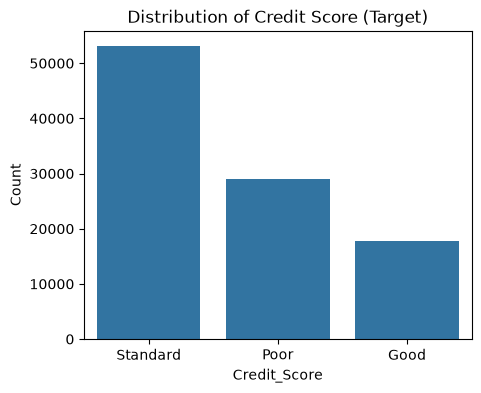

In [11]:
# Is your target categorical or continuous? is it balanced (Plot the distribution)?
# Categorical (multi-class classification): Poor / Standard / Good

print(df2['Credit_Score'].value_counts())
print(df2['Credit_Score'].value_counts(normalize=True).round(3) * 100)

plt.figure(figsize=(5,4))
sns.countplot(data=df2, x='Credit_Score', order=df2['Credit_Score'].value_counts().index)
plt.title('Distribution of Credit Score (Target)')
plt.ylabel('Count')
plt.show()

target is categorical with 3 classes, and it's moderately imbalanced — Standard 53%, Poor 29%, Good 18%

In [12]:
# What types of features do you have (categorical / numerical)? how many of each ?
cat_cols = df2.select_dtypes(include=['object','str']).columns.tolist()
num_cols = df2.select_dtypes(include='number').columns.tolist()

id_cols = ['ID', 'Customer_ID', 'SSN', 'Name', 'Month']
cat_features = [c for c in cat_cols if c not in id_cols + ['Credit_Score']]
num_features = num_cols

print(f"Categorical features ({len(cat_features)}): {cat_features}")
print(f"Numerical features  ({len(num_features)}): {num_features}")
print(f"ID / non-feature columns (excluded): {id_cols}")
print(f"Target: Credit_Score")

Categorical features (14): ['Age', 'Occupation', 'Annual_Income', 'Num_of_Loan', 'Type_of_Loan', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Credit_Mix', 'Outstanding_Debt', 'Credit_History_Age', 'Payment_of_Min_Amount', 'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance']
Numerical features  (8): ['Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Delay_from_due_date', 'Num_Credit_Inquiries', 'Credit_Utilization_Ratio', 'Total_EMI_per_month']
ID / non-feature columns (excluded): ['ID', 'Customer_ID', 'SSN', 'Name', 'Month']
Target: Credit_Score


In [13]:
# How many null values does each feature have? what's your plan for each?
df2.isnull().sum()

ID                              0
Customer_ID                     0
Month                           0
Name                         9985
Age                             0
SSN                             0
Occupation                      0
Annual_Income                   0
Monthly_Inhand_Salary       15002
Num_Bank_Accounts               0
Num_Credit_Card                 0
Interest_Rate                   0
Num_of_Loan                     0
Type_of_Loan                11408
Delay_from_due_date             0
Num_of_Delayed_Payment       7002
Changed_Credit_Limit            0
Num_Credit_Inquiries         1965
Credit_Mix                      0
Outstanding_Debt                0
Credit_Utilization_Ratio        0
Credit_History_Age           9030
Payment_of_Min_Amount           0
Total_EMI_per_month             0
Amount_invested_monthly      4479
Payment_Behaviour               0
Monthly_Balance              1200
Credit_Score                    0
dtype: int64

- Monthly_Inhand_Salary (15,002): impute with median or look to Occupation to fill with similar
- Type_of_Loan (11,408): likely no loan so impute as none
- Name (9,985): identifier, not predictive so drop column
- Credit_History_Age (9,030): impute using median or knn 
- Num_of_Delayed_Payment (7,002): impute using median or knn 
- Amount_invested_monthly (4,479): impute using median, knn or drop if possible
- Num_Credit_Inquiries (1,965): impute using median, knn or drop if possible
- Monthly_Balance (1,200): impute using median, knn or drop if possible

Credit_Score_encoded        1.000000
Monthly_Inhand_Salary       0.209318
Credit_Utilization_Ratio    0.045793
Total_EMI_per_month         0.004382
Interest_Rate              -0.002591
Num_Credit_Card            -0.007624
Num_Bank_Accounts          -0.010491
Num_Credit_Inquiries       -0.011235
Delay_from_due_date        -0.431591
Name: Credit_Score_encoded, dtype: float64


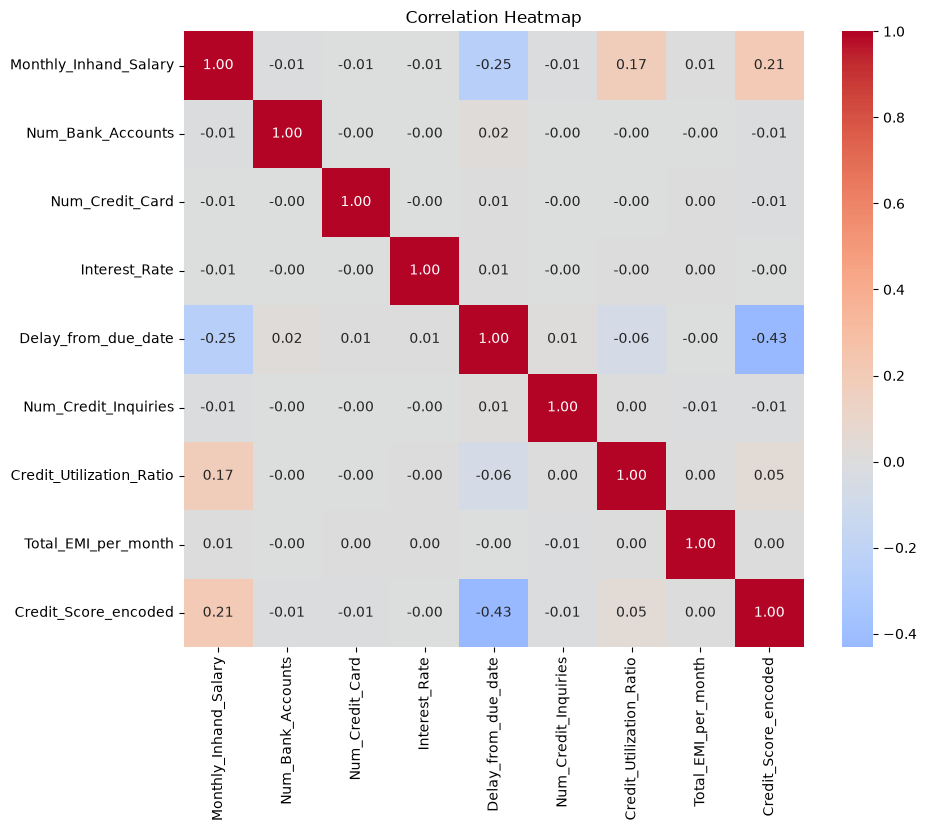

In [15]:
# Which features are most correlated with your target, and with each other?
score_map = {'Poor': 0, 'Standard': 1, 'Good': 2}
df2['Credit_Score_encoded'] = df2['Credit_Score'].map(score_map)
num_features = [c for c in num_features if c != 'Credit_Score_encoded']

corr_matrix = df2[num_features + ['Credit_Score_encoded']].corr()
corr_with_target = corr_matrix['Credit_Score_encoded'].sort_values(ascending=False)
print(corr_with_target)

plt.figure(figsize=(10,8))
sns.heatmap(df2[num_features + ['Credit_Score_encoded']].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

In [14]:
# Are there outliers? how would you handle them?
df2.describe()

,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Delay_from_due_date,Num_Credit_Inquiries,Credit_Utilization_Ratio,Total_EMI_per_month
count,84998.000000,100000.000000,100000.00000,100000.000000,100000.000000,98035.000000,100000.000000,100000.000000
mean,4194.170850,17.091280,22.47443,72.466040,21.068780,27.754251,32.285173,1403.118217
std,3183.686167,117.404834,129.05741,466.422621,14.860104,193.177339,5.116875,8306.041270
min,303.645417,-1.000000,0.00000,1.000000,-5.000000,0.000000,20.000000,0.000000
25%,1625.568229,3.000000,4.00000,8.000000,10.000000,3.000000,28.052567,30.306660
50%,3093.745000,6.000000,5.00000,13.000000,18.000000,6.000000,32.305784,69.249473
75%,5957.448333,7.000000,7.00000,20.000000,28.000000,9.000000,36.496663,161.224249
max,15204.633333,1798.000000,1499.00000,5797.000000,67.000000,2597.000000,50.000000,82331.000000


## Outliers

`describe()` reveals several invalid and implausible values across the numeric columns:

- **Num_Bank_Accounts**: min = -1 (negative account count is invalid)
- **Delay_from_due_date**: min = -5 (negative delay is invalid)
- **Interest_Rate**: max = 5,797% (not a realistic interest rate)
- **Num_Credit_Card**: max = 1,499 (not plausible for an individual)
- **Num_Credit_Inquiries**: max = 2,597 (not plausible for an individual)
- **Total_EMI_per_month**: max = 82,331 vs. 75th percentile of only 161 (extreme, isolated jump)

**Handling plan:**
- Invalid values (negative counts) → convert to NaN, then impute if possible
- Implausible extreme values (interest rate, credit card count, credit inquiries, EMI) cap at a reasonable percentile  or convert to NaN where clearly impossible, then impute if possible/applicable


# Topic 3 : Credit Card Fraud Detection

## Problem Statement

Credit card fraud causes significant financial losses for both banks and customers, and detecting it in real time is difficult because fraudulent transactions are rare and often designed to resemble legitimate activity. This project builds a classification model to predict whether a credit card transaction is fraudulent, using transaction-level, device, and behavioral features. Given the severe class imbalance typical of fraud data, the project also focuses on evaluating model performance using metrics appropriate for rare-event detection rather than raw accuracy.


## Goals
**1-** Build a binary classifier to flag fraudulent transactions from legitimate ones

**2-** Handle severe class imbalance (fraud rate ~1.7%) using appropriate techniques (class weighting, resampling, or threshold tuning)

**3-** Identify which transaction and behavioral features are most predictive of fraud

**4-** Evaluate the model using metrics suited to imbalanced classification (precision, recall, F1, PR-AUC) rather than accuracy



## Approach
**1-**  EDA — confirm class imbalance, check feature distributions, and assess data quality

**2-** Preprocessing — encode categorical features (merchant_category, card_type, auth_method, channel, device_type), scale numeric features

**3-** Address imbalance — apply class weighting and/or resampling (e.g. SMOTE) as needed

**4-** Train baseline (logistic regression) and stronger models (random forest, gradient boosting)

**5-** Evaluate with precision, recall, F1, and PR-AUC on the fraud class; interpret feature importance


## Data Info
Data Source : https://www.kaggle.com/datasets/uditjain13/credit-card-fraud-detection-2026/data

## Data Dictionary
| Column | Type | Description |
| -------- | ------- | ------- |
| transaction_id | int | unique transaction identifier |
| amount_usd | float | transaction amount in USD |
| merchant_category | string | category of the merchant |
| card_type | string | type of card used |
| auth_method | string | authentication method used |
| channel | string | transaction channel (e.g. online, in-store) |
| device_type | string | device used for the transaction |
| is_foreign_transaction | bool | whether the transaction was made abroad |
| hours_since_last_txn | float | hours since the customer's last transaction |
| txn_count_last_24h | int | number of transactions by the customer in the last 24 hours |
| distance_from_home_km | float | distance of transaction location from customer's home |
| card_age_months | int | age of the card in months |
| customer_age | int | customer's age |
| account_balance_usd | float | customer's account balance |
| is_new_merchant | bool | whether this is the customer's first transaction with this merchant |
| used_vpn | bool | whether a VPN was detected |
| ip_country_mismatch | bool | whether the IP country differs from the billing country |
| billing_shipping_mismatch | bool | whether billing and shipping addresses differ |
| cvv_retry_count | int | number of CVV entry attempts |
| velocity_score | float | score representing transaction velocity/frequency risk |
| time_of_day_hour | int | hour of day the transaction occurred |
| day_of_week | int | day of week the transaction occurred |
| merchant_risk_score | float | risk score assigned to the merchant |
| prior_disputes | int | number of prior disputes on the account |
| is_fraud | int | target variable — 1 if transaction is fraudulent, 0 otherwise |

In [15]:
df3 = pd.read_csv('./Data/Credit_Card_Fraud_Detection.csv')
df3.head()

,transaction_id,amount_usd,merchant_category,card_type,auth_method,channel,device_type,is_foreign_transaction,hours_since_last_txn,txn_count_last_24h,...,ip_country_mismatch,billing_shipping_mismatch,cvv_retry_count,velocity_score,time_of_day_hour,day_of_week,is_ai_generated_scam_attempt,merchant_risk_score,prior_disputes,is_fraud
0,1,42.86,Restaurants,Visa,OTP,Online,Android Phone,False,13.54,2,...,False,False,0,0.1,18,3,False,42.3,0,0
1,2,4.75,Online Retail,Mastercard,3D Secure,Online,Android Phone,False,0.71,2,...,False,False,0,25.8,12,4,False,28.3,0,0
2,3,77.18,Groceries,Mastercard,3D Secure,Online,Mac,False,0.35,5,...,False,True,0,42.3,5,0,False,24.7,1,0
3,4,1.69,Streaming,Visa,No Authentication,POS,Android Phone,False,3.42,6,...,False,False,0,28.9,22,6,False,56.2,1,0
4,5,261.68,Travel,Visa,3D Secure,In-App,iPhone,False,2.43,2,...,False,False,0,3.9,2,4,False,32.7,0,0


In [16]:
# What is your target column and what does it represent?
# Target: 'is_fraud' — 1 if the transaction is fraudulent, 0 if legitimate

is_fraud
0    19661
1      339
Name: count, dtype: int64
is_fraud
0    0.983
1    0.017
Name: proportion, dtype: float64


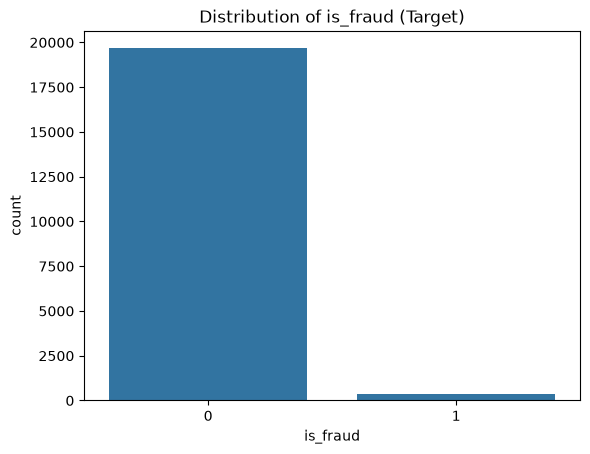

In [17]:
# Is your target categorical or continuous? is it balanced (Plot the distribution)?
print(df3['is_fraud'].value_counts())
print(df3['is_fraud'].value_counts(normalize=True).round(4))

sns.countplot(data=df3, x='is_fraud')
plt.title('Distribution of is_fraud (Target)')
plt.show()
# Categorical (binary). Severely imbalanced — ~98.3% not fraud, ~1.7% fraud.

In [18]:
# What types of features do you have (categorical / numerical)? how many of each ?
cat_cols = df3.select_dtypes(include=['object','str','bool']).columns.tolist()
num_cols = df3.select_dtypes(include='number').columns.tolist()
cat_features = [c for c in cat_cols]
num_features = [c for c in num_cols if c not in ['transaction_id', 'is_fraud']]
print(f"Categorical/boolean features ({len(cat_features)}): {cat_features}")
print(f"Numerical features ({len(num_features)}): {num_features}")

Categorical/boolean features (11): ['merchant_category', 'card_type', 'auth_method', 'channel', 'device_type', 'is_foreign_transaction', 'is_new_merchant', 'used_vpn', 'ip_country_mismatch', 'billing_shipping_mismatch', 'is_ai_generated_scam_attempt']
Numerical features (13): ['amount_usd', 'hours_since_last_txn', 'txn_count_last_24h', 'distance_from_home_km', 'card_age_months', 'customer_age', 'account_balance_usd', 'cvv_retry_count', 'velocity_score', 'time_of_day_hour', 'day_of_week', 'merchant_risk_score', 'prior_disputes']


In [20]:
# How many null values does each feature have? what's your plan for each?
df3.isnull().sum()


transaction_id                  0
amount_usd                      0
merchant_category               0
card_type                       0
auth_method                     0
channel                         0
device_type                     0
is_foreign_transaction          0
hours_since_last_txn            0
txn_count_last_24h              0
distance_from_home_km           0
card_age_months                 0
customer_age                    0
account_balance_usd             0
is_new_merchant                 0
used_vpn                        0
ip_country_mismatch             0
billing_shipping_mismatch       0
cvv_retry_count                 0
velocity_score                  0
time_of_day_hour                0
day_of_week                     0
is_ai_generated_scam_attempt    0
merchant_risk_score             0
prior_disputes                  0
is_fraud                        0
dtype: int64

is_fraud                 1.000000
cvv_retry_count          0.155509
merchant_risk_score      0.107680
velocity_score           0.097255
txn_count_last_24h       0.059866
amount_usd               0.024951
prior_disputes           0.023903
customer_age             0.019543
day_of_week              0.006071
account_balance_usd      0.004371
distance_from_home_km   -0.004292
card_age_months         -0.012065
hours_since_last_txn    -0.028798
time_of_day_hour        -0.030814
Name: is_fraud, dtype: float64


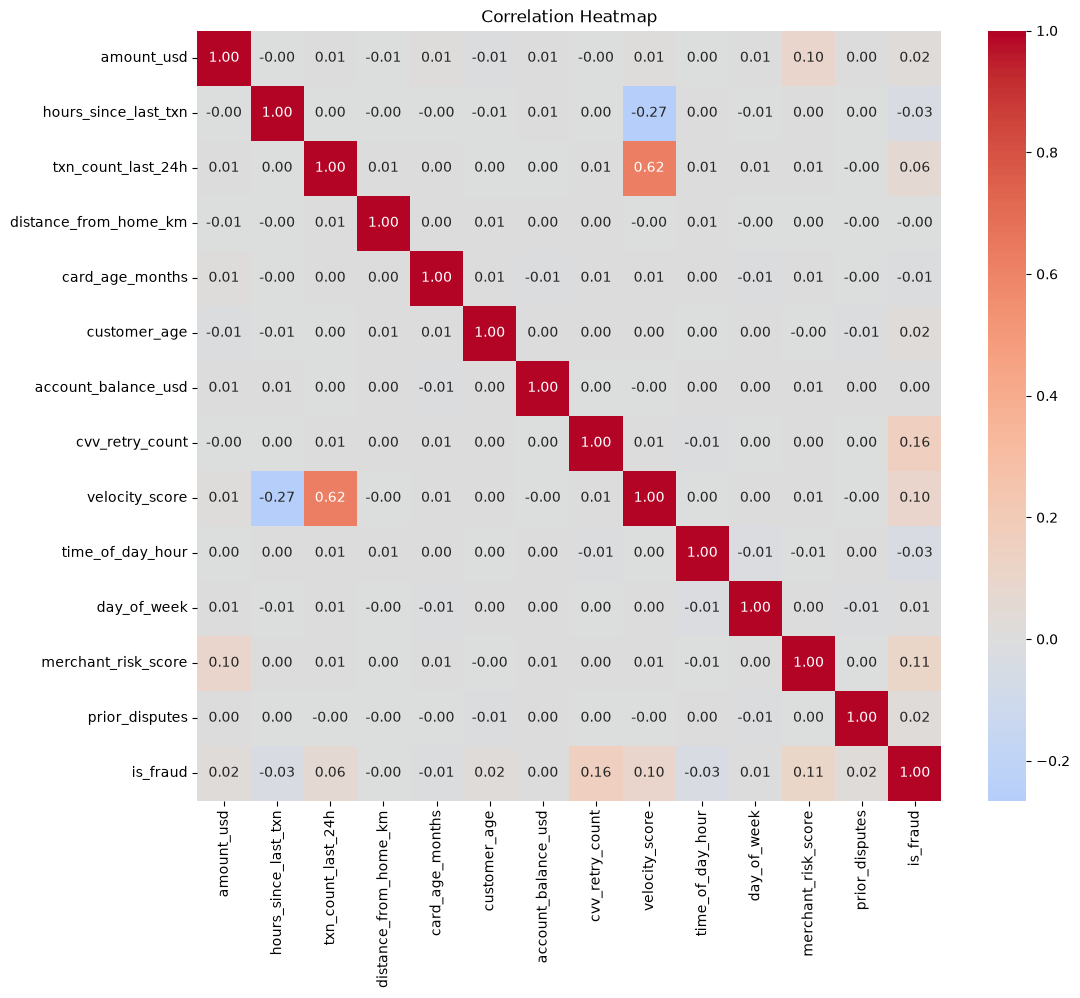

In [21]:
# Which features are most correlated with your target, and with each other?
corr_matrix = df3[num_features + ['is_fraud']].corr()
corr_with_target = corr_matrix['is_fraud'].sort_values(ascending=False)
print(corr_with_target)

plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

In [22]:
# Are there outliers? how would you handle them?
df3.describe()

,transaction_id,amount_usd,hours_since_last_txn,txn_count_last_24h,distance_from_home_km,card_age_months,customer_age,account_balance_usd,cvv_retry_count,velocity_score,time_of_day_hour,day_of_week,merchant_risk_score,prior_disputes,is_fraud
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,10000.500000,132.424597,8.950827,3.191650,22.139525,46.937550,49.669400,3316.662598,0.181300,19.807735,11.533650,2.998750,37.400390,0.281250,0.016950
std,5773.647028,256.963666,8.838745,1.779544,22.120960,6.768577,18.494032,4350.720948,0.422302,12.366301,6.925335,2.004956,17.061415,0.529209,0.129087
min,1.000000,1.000000,0.010000,0.000000,0.000000,22.000000,18.000000,52.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5000.750000,26.235000,2.590000,2.000000,6.337500,42.000000,34.000000,1019.140000,0.000000,10.700000,6.000000,1.000000,25.600000,0.000000,0.000000
50%,10000.500000,57.510000,6.210000,3.000000,15.505000,47.000000,50.000000,2007.685000,0.000000,18.800000,12.000000,3.000000,35.700000,0.000000,0.000000
75%,15000.250000,131.752500,12.432500,4.000000,30.820000,51.000000,66.000000,3944.120000,0.000000,27.600000,18.000000,5.000000,47.300000,0.000000,0.000000
max,20000.000000,6872.690000,87.050000,12.000000,216.190000,74.000000,81.000000,127125.860000,3.000000,74.400000,23.000000,6.000000,100.000000,4.000000,1.000000


- amount_usd: max = 6,872.69 vs. 75th percentile 131.75 = right-skewed, real outliers
- account_balance_usd: max = 127,125.86 vs. 75th percentile 3,944.12 = right-skewed, real outliers
  
plan:
- amount_usd, account_balance_usd: cap at a reasonable percentile (e.g. 99th)
  or log-transform to reduce skew, rather than deleting real high-value transactions